### Ortam Hazırlama

In [1]:
#Google Drive Bağlantısı
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os                        #dosya yolları ve dosya kontrolü
import random
import numpy as np
import pandas as pd              #csv dosyasını tablo gibi okumak
import matplotlib.pyplot as plt  #görsel çizmek

from PIL import Image            #görsel açmak

### Veriyi Yükleme Ve İnceleme

In [3]:
#CSV'yi okuyor ve df adında tabloya çeviriyor
csv_path = "/content/drive/MyDrive/DeepLearning_brain_project/labels.csv"
df = pd.read_csv(csv_path)

df.head()

,id,hemorrhage
0,0,1
1,1,1
2,2,1
3,3,1
4,4,1


In [4]:
#görsel klasörünü tanımla
image_folder = "/content/drive/MyDrive/DeepLearning_brain_project/head_ct"

In [5]:
#boşlukları temizler ,isimleri küçük harfe çevirir
df.columns = df.columns.str.strip().str.lower()
print(df.columns)

Index(['id', 'hemorrhage'], dtype='object')


In [6]:
#id değerini gerçek resim adına çevir
def get_image_path(image_id):
    return os.path.join(image_folder, f"{image_id:03d}.png")

In [7]:
#CSV’deki id değerlerini kullanarak her görüntünün dosya yolunu oluşturdum ve veri setine ekledim.
df["image_path"] = df["id"].apply(get_image_path)
df.head()

,id,hemorrhage,image_path
0,0,1,/content/drive/MyDrive/DeepLearning_brain_proj...
1,1,1,/content/drive/MyDrive/DeepLearning_brain_proj...
2,2,1,/content/drive/MyDrive/DeepLearning_brain_proj...
3,3,1,/content/drive/MyDrive/DeepLearning_brain_proj...
4,4,1,/content/drive/MyDrive/DeepLearning_brain_proj...


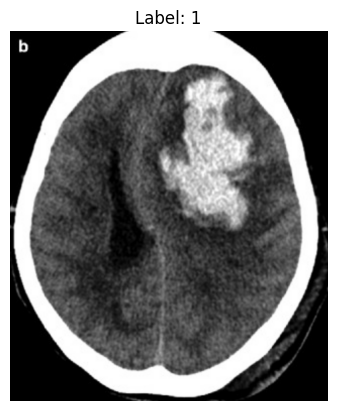

In [8]:
#İlk resmi açıp kontrol et
img = Image.open(df["image_path"][0])

plt.imshow(img, cmap="gray")
plt.title(f"Label: {df['hemorrhage'][0]}")
plt.axis("off")
plt.show()

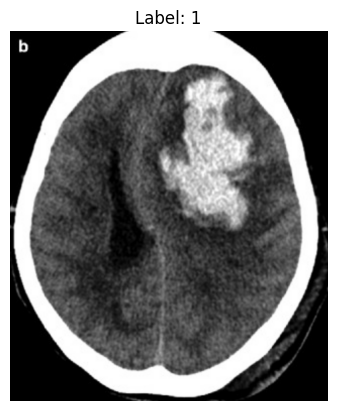

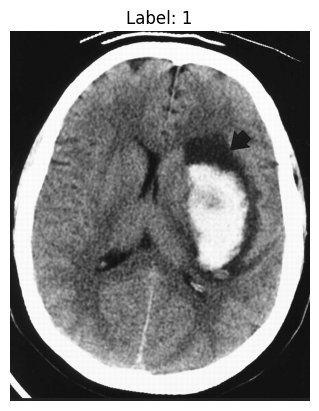

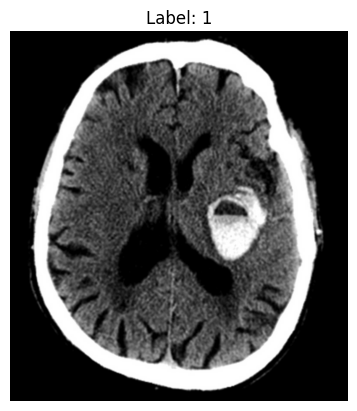

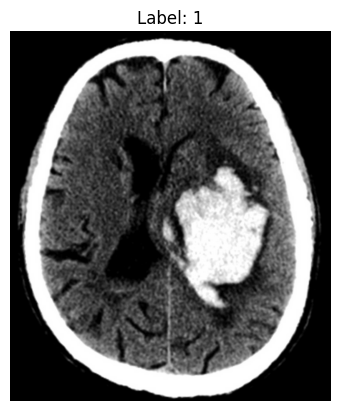

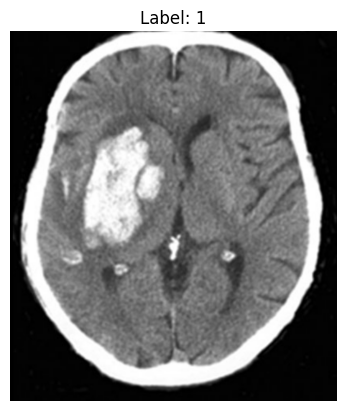

In [9]:
#Birkaç örnek görsel göster
for i in range(5):
    img = Image.open(df["image_path"][i])
    plt.figure()
    plt.imshow(img, cmap="gray")
    plt.title(f"Label: {df['hemorrhage'][i]}")
    plt.axis("off")
    plt.show()

In [10]:
#Sınıf dağılımına bak
df["hemorrhage"].value_counts()

,count
hemorrhage,
1,100
0,100


In [11]:
#Yüzde olarak dağılım
df["hemorrhage"].value_counts(normalize=True)

,proportion
hemorrhage,
1,0.5
0,0.5


In [12]:
#eksik dosya kontrolü
for path in df["image_path"]:
    if not os.path.exists(path):
        print("Eksik dosya:", path)

In [13]:
#Bir resmin boyutuna bak
img = Image.open(df["image_path"][0])
print(img.size)

(821, 957)


### TRAIN / VALIDATION / TEST AYIRMA

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
#Train ve temp olarak 2 ye ayır
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["hemorrhage"],  #Split yaparken sınıf oranını koruma
    random_state=42             #Aynı split’i tekrar üretebilme
)

In [16]:
#Sonra temp’i val ve test olarak böl
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["hemorrhage"],
    random_state=42
)

In [17]:
#Veri split = veriyi öğrenme, kontrol ve test için bölmek
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 140
Validation: 30
Test: 30


In [18]:
train_df["hemorrhage"] = train_df["hemorrhage"].astype(str)
val_df["hemorrhage"] = val_df["hemorrhage"].astype(str)
test_df["hemorrhage"] = test_df["hemorrhage"].astype(str)

In [19]:
#Sınıf dağılımı = her sınıftan kaç örnek olduğunu görmek
print(train_df["hemorrhage"].value_counts())
print(val_df["hemorrhage"].value_counts())
print(test_df["hemorrhage"].value_counts())

hemorrhage
0    70
1    70
Name: count, dtype: int64
hemorrhage
0    15
1    15
Name: count, dtype: int64
hemorrhage
0    15
1    15
Name: count, dtype: int64


### Generator + preprocessing

Generator tüm veriyi tek seferde modele vermek yerine,
-resmi dosyadan okuyor
-gerekli işlemleri yapıyor
-etiketiyle eşleştiriyor
-küçük paketler halinde modele veriyor
Bu küçük paketlere batch denir.
Mesela batch size = 16 ise:
model önce 16 resim görür.
Generator veryi modele hazırlayan ara sistem.

Preprocessing ise veriyi belli boyutlara getirip, augmentation işlemleri yapar.
 Augmentation, döndürme  ,hafif kaydırma ,zoom ,yatay çevirme işlemlerini yaparak modelin ezberlemesini azaltarak daha dayanıklı öğrenmesini sağlar.
 Bu işlem sadece train verisine uygulanır.

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

In [21]:
#Resim boyutu ve batch size
IMG_SIZE = (224, 224)  #ResNet50 için standart giriş boyutu
BATCH_SIZE = 16        #Bir seferde modele verilecek resim sayısı

In [22]:
#Train için generator tanımı
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  #Resimleri ResNet50’nin anlayacağı şekilde düzenler.
    rotation_range=10,                        #Resmi en fazla 10 derece döndürebilir.
    width_shift_range=0.10,                   #Yatayda biraz kaydırabilir.
    height_shift_range=0.10,                  #Dikeyde biraz kaydırabilir.
    zoom_range=0.10,                          #Biraz yakınlaştırabilir.
    horizontal_flip=True                      #Yatay aynalama yapabilir.
)

In [23]:
#Validation ve test için generator tanımı
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input  #Sadece ResNet50 preprocessing yapıyor.Augmentation yok.
)

In [24]:
#Train generator kurulumu
# Convert 'hemorrhage' column to string type for binary classification
train_df['hemorrhage'] = train_df['hemorrhage'].astype(str)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",                    #Girdi olarak resim yolu sütununu kullanıyor.
    y_col="hemorrhage",                    #Etiket olarak hemorrhage sütununu kullanıyor.
    target_size=IMG_SIZE,                  #Bütün resimleri 224x224 yapıyor.
    color_mode="rgb",                      #Resimleri 3 kanallı hale getiriyor.çünkü ResNet50 3 kanallı giriş bekler
    class_mode="binary",                   #İki sınıf olduğu için binary sınıflandırma yapıyoruz.
    batch_size=BATCH_SIZE,                 #Bir seferde 16 resim verilecek.
    shuffle=True                           #Train verisi karıştırılır.
)

Found 140 validated image filenames belonging to 2 classes.


In [25]:
#Validation generator
# Convert 'hemorrhage' column to string type for binary classification
val_df['hemorrhage'] = val_df['hemorrhage'].astype(str)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="hemorrhage",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 30 validated image filenames belonging to 2 classes.


In [26]:
#Test generator
# Convert 'hemorrhage' column to string type for binary classification
test_df['hemorrhage'] = test_df['hemorrhage'].astype(str)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="hemorrhage",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 30 validated image filenames belonging to 2 classes.


In [27]:
print("Train sınıf eşleşmesi:", train_generator.class_indices)
print("Validation sınıf eşleşmesi:", val_generator.class_indices)
print("Test sınıf eşleşmesi:", test_generator.class_indices)

Train sınıf eşleşmesi: {'0': 0, '1': 1}
Validation sınıf eşleşmesi: {'0': 0, '1': 1}
Test sınıf eşleşmesi: {'0': 0, '1': 1}


In [28]:
images, labels = next(train_generator)

print("Görüntü batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Görüntü batch shape: (16, 224, 224, 3)
Label batch shape: (16,)


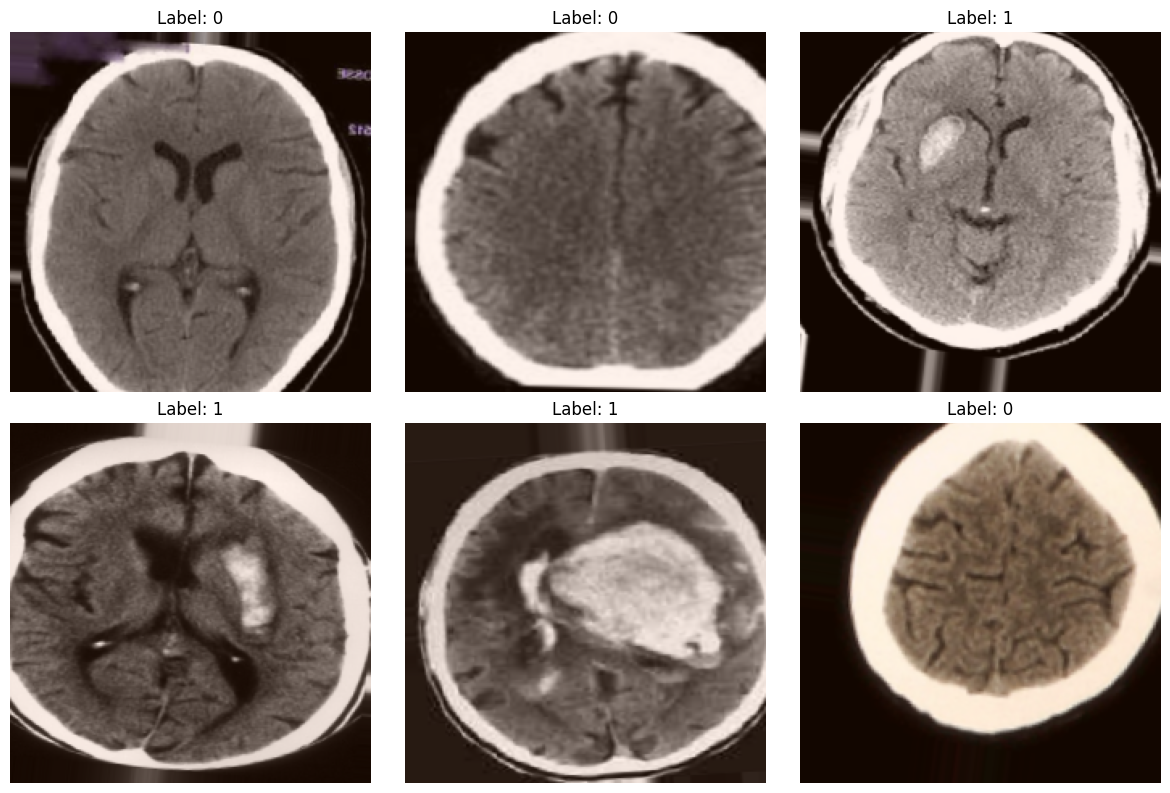

In [29]:
plt.figure(figsize=(12, 8))

for i in range(6):
    plt.subplot(2, 3, i+1)

    img = images[i]
    img_display = (img - img.min()) / (img.max() - img.min() + 1e-8)

    plt.imshow(img_display)
    plt.title(f"Label: {int(labels[i])}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### ResNet50 model kurma
ResNet50, önceden çok büyük bir veri seti üzerinde eğitilmiş hazır bir CNN modelidir.

Yani bu model:
kenar ,doku ,şekil ,genel görüntü özellikleri gibi şeyleri zaten öğrenmiş durumda.

Biz bunu sıfırdan eğitmek yerine, hazır bilgisini kullanacağız.
Buna transfer learning denir.

ResNet50’yi iki parçalı düşün:

Alt kısım :Görüntüden özellik çıkaran güçlü hazır yapı

Üst kısım :Son karar veren sınıflandırma katmanları

Biz alt kısmı hazır kullanacağız ve üstte kendi problemimize uygun yeni katman ekleyeceğiz Çünkü bizim problemimiz:iki sınıf hemorrhage var / yok

İlk başta ResNet50’nin ana gövdesini eğitmeyeceğiz. Çünkü veri az, model çok büyük ,hemen her şeyi açarsak ezberleme olabilir. Bu yüzden ilk eğitimde:

ResNet50 gövdesi sabit
sadece bizim eklediğimiz katmanlar öğreniyor

Buna:
feature extraction aşaması diyebilirsin.

In [30]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [31]:
#Taban Modeli Kuruyoruz
base_model = ResNet50(
    weights="imagenet",      #Model hazır ağırlıklarla gelsin
    include_top=False,       #ResNet50’nin kendi son sınıflandırma kısmını alma.Biz Kendimiz ekleyeceğiz
    input_shape=(224, 224, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [32]:
base_model.trainable = False #ResNet50’nin ana katmanları şu an öğrenmeyecek.  Taban modeli dondur.

In [33]:
#Üst katmanları ekle
x = base_model.output                      #ResNet50’den çıkan son özellik haritalarını alıyoruz.
x = GlobalAveragePooling2D()(x)            #ResNet50’nin sonundaki çok boyutlu bir çıktıyı düz ve daha yönetilebilir bir vektöre çeviriyoruz.
x = Dropout(0.3)(x)                        #Nöronların bir kısmını rastgele kapatır.
x = Dense(128, activation="relu")(x)       #ResNet50’den gelen özellikleri işler
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x) #Çıkış katmanı

In [34]:
#Tam modeli oluştur
model = Model(inputs=base_model.input, outputs=output)  #ResNet50 tabanı ile bizim eklediğimiz yeni üst katmanları birleştirip tam modeli kuruyor.

In [35]:
#Modeli derle
model.compile(
    optimizer=Adam(learning_rate=1e-4),    #Modelin nasıl öğreneceğini belirler.Öğrenme hızı
    loss="binary_crossentropy",            #Kayıp fonksiyonu
    metrics=["accuracy"]                   #Eğitim sırasında doğruluğu da takip et
)

In [36]:
#Model özetini gör
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [37]:
#Callback’leri tanımla
early_stopping = EarlyStopping(
    monitor="val_loss",            #Validation loss düzelmeyi bırakırsa eğitimi durdurur.
    patience=5,                    #5 epoch boyunca iyileşme yoksa dur
    restore_best_weights=True      #En iyi epoch’un ağırlıklarını geri yükle
)

checkpoint = ModelCheckpoint(
    "best_resnet50_model.keras",   #En iyi modeli dosyaya kaydeder.
    monitor="val_loss",
    save_best_only=True
)

In [38]:
#Modeli eğit
history = model.fit(
    train_generator,                 #train_generator ile öğreniyor
    validation_data=val_generator,   #val_generator ile kontrol ediyor
    epochs=20,                       #20 epoch’a kadar gider
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 71s 7s/step - accuracy: 0.4714 - loss: 0.8780 - val_accuracy: 0.7667 - val_loss: 0.5923
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 0.6000 - loss: 0.7574 - val_accuracy: 0.7667 - val_loss: 0.5124
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.6286 - loss: 0.7040 - val_accuracy: 0.7333 - val_loss: 0.4798
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.6857 - loss: 0.5826 - val_accuracy: 0.8333 - val_loss: 0.3903
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 0.7571 - loss: 0.5227 - val_accuracy: 0.8000 - val_loss: 0.3483
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.7571 - loss: 0.4923 - val_accuracy: 0.7667 - val_loss: 0.3367
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.7500 - loss: 0.4812 - val_accuracy: 0.9000 - val_loss: 0.2930
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.8643 - loss: 0.3580 - val_accuracy: 0.9000 - val_loss: 0.2800
Epoch 9/

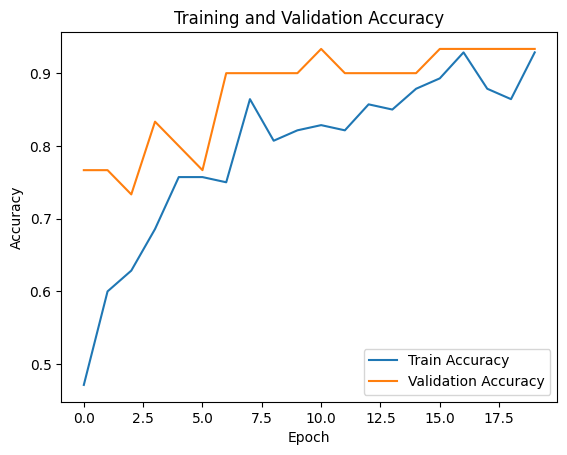

In [39]:
#Accuracy grafiği
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.show()

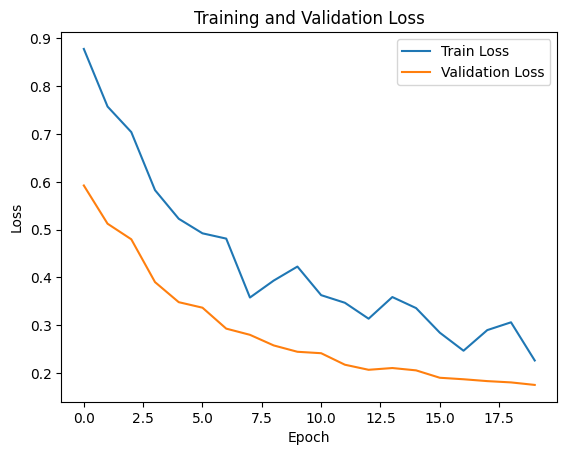

In [40]:
#Loss grafiği
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

### Test setinde değerlendirme
Şimdi eğitim bitti.
Artık modeli hiç görmediği test verisi üzerinde ölçeceğiz.

In [41]:
#Test accuracy ve loss     ---modelin gerçek performansını ilk kez burada görüyoruz.
test_loss, test_acc = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.9667 - loss: 0.1656
Test Loss: 0.16560901701450348
Test Accuracy: 0.9666666388511658


In [42]:
#Tahmin olasılıklarını al
y_pred_prob = model.predict(test_generator)

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step


In [43]:
#Olasılığı sınıfa çevir olasılığı sınıf etiketine çeviriyoruz.
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

In [44]:
#Gerçek etiketleri al  modelin tahmini → y_pred   gerçek etiket → y_true
y_true = test_generator.classes

### Confusion matrix

In [45]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

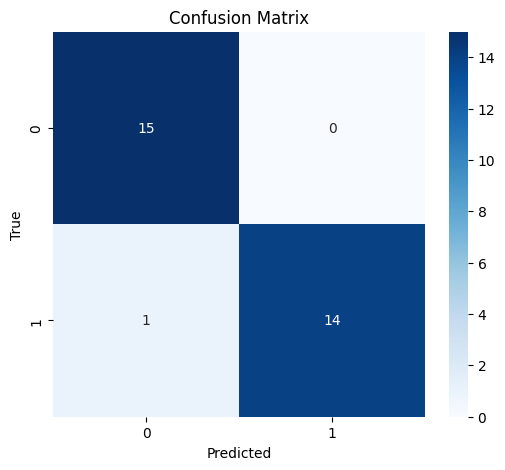

In [46]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [47]:
#Accuracy, Precision, Recall, F1
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1-score :", f1_score(y_true, y_pred))

Accuracy : 0.9666666666666667
Precision: 1.0
Recall   : 0.9333333333333333
F1-score : 0.9655172413793104


In [48]:
#Detaylı classification report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       1.00      0.93      0.97        15

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### Hyperparameter Tuning

In [49]:
learning_rates = [1e-4, 1e-5]
batch_sizes = [16,32]
dropouts = [0.3]
patiences=[3,5]
epochs_list = [10, 15]

In [50]:
from itertools import product
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import precision_score, recall_score
import numpy as np
import pandas as pd

def build_tuning_model(lr, dropout_rate):
    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


def create_generators_for_tuning(batch_size):
    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col="image_path",
        y_col="hemorrhage",
        target_size=(224, 224),
        color_mode="rgb",
        class_mode="binary",
        batch_size=batch_size,
        shuffle=True
    )

    val_gen = val_test_datagen.flow_from_dataframe(
        dataframe=val_df,
        x_col="image_path",
        y_col="hemorrhage",
        target_size=(224, 224),
        color_mode="rgb",
        class_mode="binary",
        batch_size=batch_size,
        shuffle=False
    )
    return train_gen, val_gen


def run_experiment(exp_no, lr, batch_size, dropout, patience, epochs):
    print(f"Deney {exp_no}: LR={lr}, Batch={batch_size}, Dropout={dropout}, Patience={patience}, Epoch={epochs}")

    model = build_tuning_model(lr, dropout)
    train_gen, val_gen = create_generators_for_tuning(batch_size)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=[early_stop],
        verbose=1
    )

    actual_epochs = len(history.history["loss"])
    best_val_loss = float(np.min(history.history["val_loss"]))
    best_val_acc = float(np.max(history.history["val_accuracy"]))

    val_gen.reset()
    y_prob = model.predict(val_gen, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = val_gen.classes

    val_prec = precision_score(y_true, y_pred, zero_division=0)
    val_recall = recall_score(y_true, y_pred, zero_division=0)

    return {
        "Exp": exp_no,
        "LR": f"{lr:.0e}",
        "Batch": batch_size,
        "Dropout": dropout,
        "Patience": patience,
        "Epoch": epochs,
        "Epochs (actual)": actual_epochs,
        "Val Loss": round(best_val_loss, 4),
        "Val Acc": round(best_val_acc, 4),
        "Val Prec": round(val_prec, 4),
        "Val Recall": round(val_recall, 4),
    }

In [51]:
# Tüm kombinasyonları çalıştır
grid_results = []
combinations = list(product(learning_rates, batch_sizes, dropouts, patiences, epochs_list))

for exp_no, (lr, batch, drop, patience, epochs) in enumerate(combinations, start=1):
    result = run_experiment(exp_no, lr, batch, drop, patience, epochs)
    grid_results.append(result)

grid_results_df = pd.DataFrame(grid_results)
grid_results_df = grid_results_df.sort_values(
    by=["Val Acc", "Val Recall", "Val Prec", "Val Loss"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

grid_results_df

Deney 1: LR=0.0001, Batch=16, Dropout=0.3, Patience=3, Epoch=10
Found 140 validated image filenames belonging to 2 classes.
Found 30 validated image filenames belonging to 2 classes.
Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step - accuracy: 0.5357 - loss: 0.8645 - val_accuracy: 0.6333 - val_loss: 0.5887
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.6357 - loss: 0.7162 - val_accuracy: 0.8333 - val_loss: 0.4842
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.6714 - loss: 0.6607 - val_accuracy: 0.8333 - val_loss: 0.4262
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.6643 - loss: 0.6356 - val_accuracy: 0.8333 - val_loss: 0.3993
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.7286 - loss: 0.5627 - val_accuracy: 0.9333 - val_loss: 0.3399
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.7357 - loss: 0.4675 - val_accuracy: 0.9667 - val_loss: 0.3098
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.8143 - loss

Deney 3: LR=0.0001, Batch=16, Dropout=0.3, Patience=5, Epoch=10
Found 140 validated image filenames belonging to 2 classes.
Found 30 validated image filenames belonging to 2 classes.
Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.5286 - loss: 0.8846 - val_accuracy: 0.6667 - val_loss: 0.5615
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.5357 - loss: 0.8049 - val_accuracy: 0.9333 - val_loss: 0.4449
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.7071 - loss: 0.6347 - val_accuracy: 0.8667 - val_loss: 0.3871
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.6786 - loss: 0.5873 - val_accuracy: 0.9000 - val_loss: 0.3604
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.8357 - loss: 0.4093 - val_accuracy: 0.9333 - val_loss: 0.3043
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.8357 - loss: 0.3889 - val_accuracy: 0.9333 - val_loss: 0.2699
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 0.8000 - loss

,Exp,LR,Batch,Dropout,Patience,Epoch,Epochs (actual),Val Loss,Val Acc,Val Prec,Val Recall
0,3,1e-04,16,0.3,5,10,10,0.2055,0.9667,0.9375,1.0000
1,1,1e-04,16,0.3,3,10,10,0.2481,0.9667,0.9375,1.0000
2,5,1e-04,32,0.3,3,10,10,0.2963,0.9667,1.0000,0.9333
3,6,1e-04,32,0.3,3,15,15,0.2229,0.9667,0.9333,0.9333
4,4,1e-04,16,0.3,5,15,15,0.1999,0.9333,0.9333,0.9333
5,7,1e-04,32,0.3,5,10,10,0.2543,0.9333,0.9333,0.9333
6,2,1e-04,16,0.3,3,15,15,0.2159,0.9333,0.9286,0.8667
7,8,1e-04,32,0.3,5,15,15,0.2365,0.9333,1.0000,0.7333
8,14,1e-05,32,0.3,3,15,15,0.5153,0.8667,0.8667,0.8667
9,15,1e-05,32,0.3,5,10,10,0.5704,0.7667,0.8333,0.6667


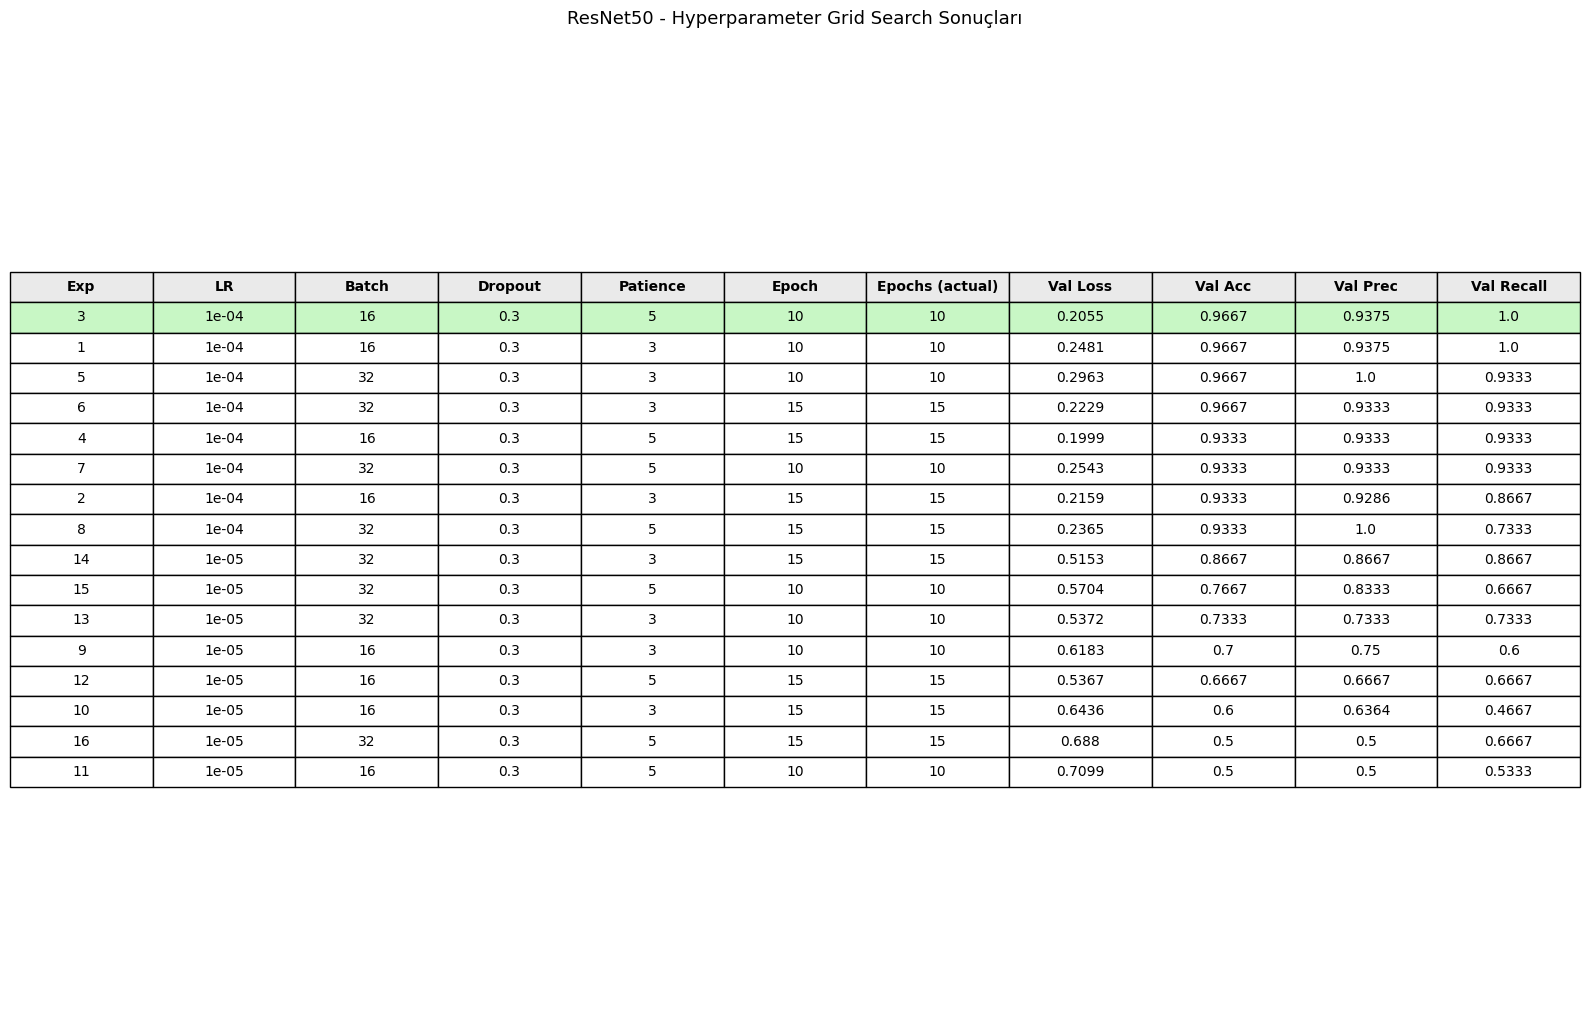

Tablo kaydedildi: grid_search_table.png


In [52]:
# Sonuçları görsel tablo olarak kaydet
import matplotlib.pyplot as plt

display_df = grid_results_df.copy()

fig, ax = plt.subplots(figsize=(16, max(4, 0.55 * len(display_df) + 1.5)))
ax.axis("off")

table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Başlık satırı
for j in range(len(display_df.columns)):
    table[0, j].set_facecolor("#EAEAEA")
    table[0, j].set_text_props(weight="bold")

# En iyi satırı yeşil yap
if len(display_df) > 0:
    for j in range(len(display_df.columns)):
        table[1, j].set_facecolor("#c8f7c5")

plt.title("ResNet50 - Hyperparameter Grid Search Sonuçları", fontsize=13, pad=18)
plt.tight_layout()
plt.savefig("grid_search_table.png", dpi=200, bbox_inches="tight")
plt.show()

print("Tablo kaydedildi: grid_search_table.png")

Bu çalışmada hiperparametre ayarı kapsamında learning rate (1e-3, 1e-4, 1e-5), batch size (8, 16) ve dropout (0.3, 0.5) değerleri denenmiştir. Epoch sayısı ve early stopping parametreleri sabit tutulmuştur. Tüm kombinasyonlar grid search yaklaşımıyla test edilmiş ve sonuçlar tablo halinde karşılaştırılmıştır.

Sonuçlara göre en yüksek doğruluk değeri learning rate = 1e-4 ve dropout = 0.3/0.5 kombinasyonlarında elde edilmiştir. Daha düşük learning rate değerlerinde modelin öğrenme performansı belirgin şekilde düşmüştür.

### Fine Tuning
ResNet50’nin tamamını değil son birkaç katmanını açacağız
böylece model senin CT verine biraz daha özel uyum sağlayacak

In [53]:
#En iyi modeli yükle
from tensorflow.keras.models import load_model

model = load_model("best_resnet50_model.keras")
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,374,917 (92.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 524,804 (2.00 MB)

In [54]:
#Katmanları görelim
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.trainable)

0 input_layer True
1 conv1_pad False
2 conv1_conv False
3 conv1_bn False
4 conv1_relu False
5 pool1_pad False
6 pool1_pool False
7 conv2_block1_1_conv False
8 conv2_block1_1_bn False
9 conv2_block1_1_relu False
10 conv2_block1_2_conv False
11 conv2_block1_2_bn False
12 conv2_block1_2_relu False
13 conv2_block1_0_conv False
14 conv2_block1_3_conv False
15 conv2_block1_0_bn False
16 conv2_block1_3_bn False
17 conv2_block1_add False
18 conv2_block1_out False
19 conv2_block2_1_conv False
20 conv2_block2_1_bn False
21 conv2_block2_1_relu False
22 conv2_block2_2_conv False
23 conv2_block2_2_bn False
24 conv2_block2_2_relu False
25 conv2_block2_3_conv False
26 conv2_block2_3_bn False
27 conv2_block2_add False
28 conv2_block2_out False
29 conv2_block3_1_conv False
30 conv2_block3_1_bn False
31 conv2_block3_1_relu False
32 conv2_block3_2_conv False
33 conv2_block3_2_bn False
34 conv2_block3_2_relu False
35 conv2_block3_3_conv False
36 conv2_block3_3_bn False
37 conv2_block3_add False
38 conv2_b

In [55]:
#Son katmanları aç  son 30 katman hariç her şeyi kapatıyon son 30 katmanı öğrenebilir hale getiriyor
for layer in model.layers[:-30]:
    layer.trainable = False

for layer in model.layers[-30:]:
    layer.trainable = True

In [56]:
#Modeli küçük learning rate ile tekrar derle
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [57]:
#Fine-tuning callback’leri
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping_ft = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint_ft = ModelCheckpoint(
    "best_resnet50_finetuned.keras",
    monitor="val_loss",
    save_best_only=True
)

In [58]:
#Fine-tuning eğitimi
history_ft = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stopping_ft, checkpoint_ft]
)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 60s 5s/step - accuracy: 0.8500 - loss: 0.3831 - val_accuracy: 0.9000 - val_loss: 0.1757
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 44s 5s/step - accuracy: 0.8000 - loss: 0.3890 - val_accuracy: 0.8667 - val_loss: 0.1867
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 44s 5s/step - accuracy: 0.8786 - loss: 0.2934 - val_accuracy: 0.8667 - val_loss: 0.1963
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 44s 5s/step - accuracy: 0.9286 - loss: 0.2421 - val_accuracy: 0.8667 - val_loss: 0.2049
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 48s 5s/step - accuracy: 0.8857 - loss: 0.2703 - val_accuracy: 0.8667 - val_loss: 0.2086
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 43s 5s/step - accuracy: 0.9286 - loss: 0.2197 - val_accuracy: 0.8667 - val_loss: 0.2041


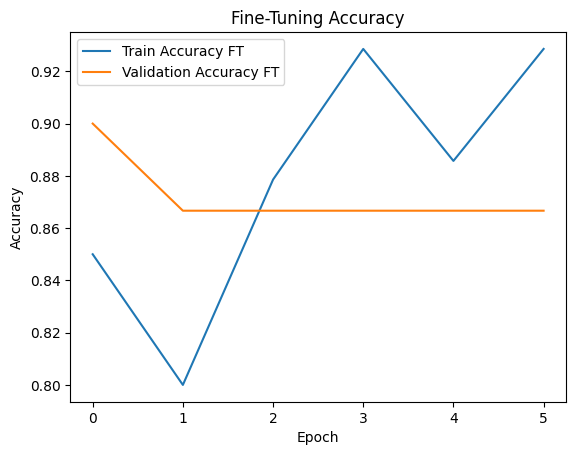

In [59]:
#fine-tuning sonrası değerlendirme
#Accuracy grafiği
plt.plot(history_ft.history["accuracy"], label="Train Accuracy FT")
plt.plot(history_ft.history["val_accuracy"], label="Validation Accuracy FT")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Fine-Tuning Accuracy")
plt.show()

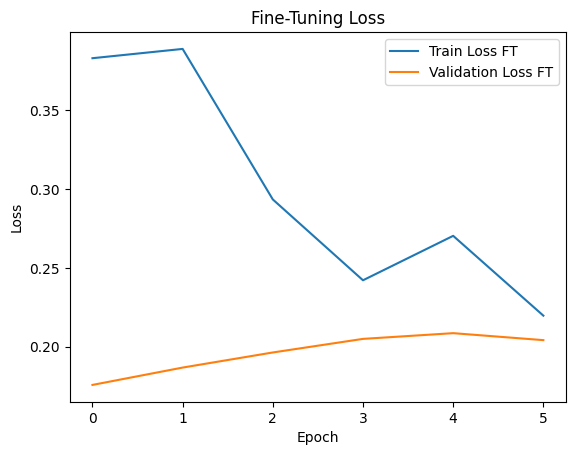

In [60]:
#Loss grafiği
plt.plot(history_ft.history["loss"], label="Train Loss FT")
plt.plot(history_ft.history["val_loss"], label="Validation Loss FT")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Fine-Tuning Loss")
plt.show()

In [61]:
#Test setinde değerlendirme
test_loss_ft, test_acc_ft = model.evaluate(test_generator)

print("Fine-Tuned Test Loss:", test_loss_ft)
print("Fine-Tuned Test Accuracy:", test_acc_ft)

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.9667 - loss: 0.1697
Fine-Tuned Test Loss: 0.16972984373569489
Fine-Tuned Test Accuracy: 0.9666666388511658


In [62]:
#Tahminleri al
y_pred_prob_ft = model.predict(test_generator)
y_pred_ft = (y_pred_prob_ft > 0.5).astype(int).flatten()

y_true = test_generator.classes

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 6s/step


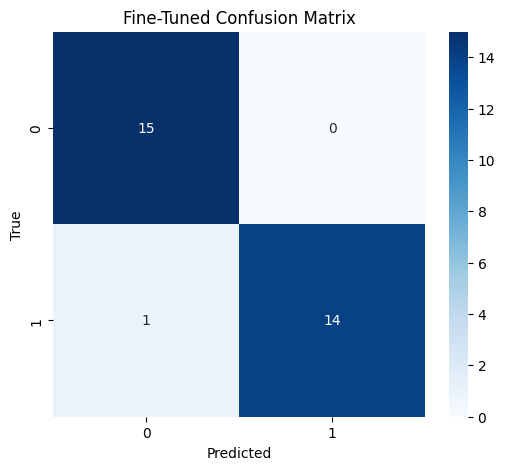

In [63]:
#Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

cm_ft = confusion_matrix(y_true, y_pred_ft)

plt.figure(figsize=(6,5))
sns.heatmap(cm_ft, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Fine-Tuned Confusion Matrix")
plt.show()

In [64]:
#Metrikler
print("Accuracy :", accuracy_score(y_true, y_pred_ft))
print("Precision:", precision_score(y_true, y_pred_ft))
print("Recall   :", recall_score(y_true, y_pred_ft))
print("F1-score :", f1_score(y_true, y_pred_ft))

print(classification_report(y_true, y_pred_ft))

Accuracy : 0.9666666666666667
Precision: 1.0
Recall   : 0.9333333333333333
F1-score : 0.9655172413793104
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       1.00      0.93      0.97        15

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



Model ilk aşamada transfer learning ile eğitilmiş ve %93 doğruluk elde edilmiştir. Daha sonra fine-tuning uygulanarak modelin son katmanları yeniden eğitilmiş ancak performansta anlamlı bir artış gözlemlenmemiştir. Bu durum, veri setinin küçük olması ve modelin başlangıçta zaten yüksek performans göstermesi ile açıklanabilir.